**Table of contents**<a id='toc0_'></a>    
- [Validating the simulation framework](#toc1_)    
  - [Continuous excitation](#toc1_1_)    
    - [Irradiance saturation of a two state system](#toc1_1_1_)    
      - [Simulation](#toc1_1_1_1_)    
      - [Calculation](#toc1_1_1_2_)    
    - [Second order coherence shows antibunching](#toc1_1_2_)    
  - [Multiple fluorophores](#toc1_2_)    
    - [Second order coherence shows less antibunching](#toc1_2_1_)    
    - [Additive fluorescence](#toc1_2_2_)    
    - [Multiple lifetime components](#toc1_2_3_)    
  - [Detailed photophysical models in FCS](#toc1_3_)    
    - [Widengren et al.: Fitting Cy5 FCS curve](#toc1_3_1_)    
      - [Simulation](#toc1_3_1_1_)    
      - [Fit](#toc1_3_1_2_)    
    - [Widengren et al.: Modulating irradiance for Cy5 FCS curve](#toc1_3_2_)    
  - [*d*STORM](#toc1_4_)    
    - [Gidi et al.: Concentration of MEA (or $\beta$-ME) has linear effect on T1 decay rate](#toc1_4_1_)    
    - [Gidi et al.: Increase in irradiance leads to shorter ON times](#toc1_4_2_)    
  - [Energy transfers](#toc1_5_)    
    - [Singlet-singlet annihilation restores antibunching](#toc1_5_1_)    
    - [homo-FRET](#toc1_5_2_)    
    - [Shorter fluorescence lifetime and less fluorescence](#toc1_5_3_)    
  - [TCSPC](#toc1_6_)    
    - [Second order coherence peaks at every between-pulse-time](#toc1_6_1_)    
    - [Long fluorescence lifetimes are seen as short fluorescence lifetimes (Aliasing)](#toc1_6_2_)    
  - [Figure](#toc1_7_)    
    - [Figure 1](#toc1_7_1_)    
    - [Figure 2](#toc1_7_2_)    

<!-- vscode-jupyter-toc-config
	numbering=false
	anchor=true
	flat=false
	minLevel=1
	maxLevel=6
	/vscode-jupyter-toc-config -->
<!-- THIS CELL WILL BE REPLACED ON TOC UPDATE. DO NOT WRITE YOUR TEXT IN THIS CELL -->

# <a id='toc1_'></a>[Validating the simulation framework](#toc0_)

In [1]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib import rcParams

import fluopy.analysis as an
import fluopy.blinking as bl
import fluopy.emissions as em
import fluopy.fcs as fcs_p
import fluopy.figure as fi
import fluopy.fluorophores as fl
import fluopy.formulas as fo
import fluopy.prediction as pr
import fluopy.simulation as si
import fluopy.transitions as tr

%load_ext autoreload
%autoreload 2

import warnings


def custom_warning_format(msg, category, filename, lineno, line=None):
    if line is None:
        import linecache

        line = linecache.getline(filename, lineno)
    check = ["Floating point precision", "not known"]
    if any(checking in str(msg) for checking in check):
        return ""
    return f"WARNING for line: {line} {msg} \n"


warnings.formatwarning = custom_warning_format

saving_at = r"D:\python_output\Chapter_I\1_3_validations"

## <a id='toc1_1_'></a>[Continuous excitation](#toc0_)

### <a id='toc1_1_1_'></a>[Irradiance saturation of a two state system](#toc0_)
Demonstrates a correct implementation of excitation rate calculation given an irradiance

#### <a id='toc1_1_1_1_'></a>[Simulation](#toc0_)

In [29]:
rng = np.random.default_rng(1)
fluorophore = fl.Fluorophore(name="S0S1System", position=[0, 0])
fluorophore_system = fl.FluorophoreSystem(fluorophores=[fluorophore])
irradiances_saturation = np.logspace(-2, 5, 8)
photons_per_frame_collection_saturation = []
transitions = [
    tr.Transition(
        tr.TransitionType.INTERNAL_CONVERSION_S, rate=4.2e8, fluorophore_ids=[0]
    ),
    tr.Transition(
        tr.TransitionType.FLUORESCENT_EMISSION, rate=1.6e8, fluorophore_ids=[0]
    ),
]
_, _, frequency = fo.convert_wavenumber_wavelength_frequency(wavelength=640)
for irradiance in irradiances_saturation:
    photon_flux = fo.calculate_photon_flux(
        irradiance=irradiance,
        frequency=frequency,
    )
    excitation_rate = fo.calculate_excitation_rate(
        photon_flux=photon_flux,
        absorption_cross_section=8.1e-16,
    )

    excitation = [
        tr.Transition(
            tr.TransitionType.EXCITATION,
            rate=excitation_rate,
            fluorophore_ids=[0],
        )
    ]
    transition_set = tr.TransitionSet(
        {"S0S1System": transitions + excitation}, fluorophore_system
    )
    transition_set.finalize()
    simulation = si.Simulation(transition_set)
    simulation.run(size=1e7, seed=rng)
    emissions = em.Emissions()
    emissions.extract(simulation)
    photons_per_frame = emissions.event_time_series.mean()
    photons_per_frame_collection_saturation.append(photons_per_frame)

#### <a id='toc1_1_1_2_'></a>[Calculation](#toc0_)

In [30]:
k_s1 = 1.6e8 + 4.2e8
relative_photon_rate_collection_saturation = []
for irradiance in irradiances_saturation:
    photon_flux = fo.calculate_photon_flux(
        irradiance=irradiance,
        frequency=frequency,
    )
    excitation_rate = fo.calculate_excitation_rate(
        photon_flux=photon_flux,
        absorption_cross_section=8.1e-16,
    )
    relative_photon_rate = excitation_rate / (excitation_rate + k_s1)
    relative_photon_rate_collection_saturation.append(relative_photon_rate)

### <a id='toc1_1_2_'></a>[Second order coherence shows antibunching](#toc0_)
Demonstrates that a single fluorophore shows the expected antibunching drop indicating a proper implementation of excitation/fluorescence dynamics

In [49]:
rng = np.random.default_rng(2)
fluorophore = fl.Fluorophore(name="S0S1System", position=[0, 0])
fluorophore_system = fl.FluorophoreSystem(fluorophores=[fluorophore])
transitions = [
    tr.Transition(
        tr.TransitionType.INTERNAL_CONVERSION_S, rate=4.2e8, fluorophore_ids=[0]
    ),
    tr.Transition(
        tr.TransitionType.FLUORESCENT_EMISSION, rate=1.6e8, fluorophore_ids=[0]
    ),
    tr.Transition(
        tr.TransitionType.EXCITATION,
        rate=7.3e6,
        fluorophore_ids=[0],
    ),
]
transition_set = tr.TransitionSet({"S0S1System": transitions}, fluorophore_system)
transition_set.finalize()
simulation = si.Simulation(transition_set)
simulation.run(size=4e6, seed=rng)
emissions = em.Emissions()
emissions.extract(simulation)
hist_antibunch, bins_antibunch = fcs_p.coincidence(
    emissions.event_time_points, 1e-7, 1e-10, seed=rng
)

## <a id='toc1_2_'></a>[Multiple fluorophores](#toc0_)

### <a id='toc1_2_1_'></a>[Second order coherence shows less antibunching](#toc0_)
Demonstrates that multiple, non-interacting fluorophores have the expected effect on photon antibunching

In [32]:
rng = np.random.default_rng(3)
fluorophores = fl.construct_fluorophores(
    name="S0S1System", count=4, distance=3, shape="square"
)
fluorophore_system = fl.FluorophoreSystem(fluorophores=fluorophores)
transitions = [
    tr.Transition(
        tr.TransitionType.INTERNAL_CONVERSION_S,
        rate=4.2e8,
        fluorophore_ids=[0, 1, 2, 3],
    ),
    tr.Transition(
        tr.TransitionType.FLUORESCENT_EMISSION, rate=1.6e8, fluorophore_ids=[0, 1, 2, 3]
    ),
    tr.Transition(
        tr.TransitionType.EXCITATION,
        rate=7.3e6,
        fluorophore_ids=[0, 1, 2, 3],
    ),
]
transition_set = tr.TransitionSet({"S0S1System": transitions}, fluorophore_system)
transition_set.finalize()
simulation = si.Simulation(transition_set)
simulation.run(size=2e6, seed=rng)
emissions = em.Emissions()
emissions.extract(simulation)

hist_multi_f, bins_multi_f = fcs_p.coincidence(
    emissions.event_time_points, 1e-7, 1e-10, seed=rng
)

### <a id='toc1_2_2_'></a>[Additive fluorescence](#toc0_)
Demonstrates that if no energy transfer or other disturbances, than the intensity scales proportional to the number of fluorophores

In [33]:
rng = np.random.default_rng(4)
num_fluorophores = [1, 2, 3, 4, 5, 6]
photons_per_frame_collection_num_f = []
for num in num_fluorophores:
    fluorophores = fl.construct_fluorophores(
        name="S0S1System", count=num, distance=3, shape="square"
    )
    fluorophore_system = fl.FluorophoreSystem(fluorophores=fluorophores)
    ids = np.arange(num, dtype=int).tolist()
    transitions = [
        tr.Transition(
            tr.TransitionType.INTERNAL_CONVERSION_S, rate=4.2e8, fluorophore_ids=ids
        ),
        tr.Transition(
            tr.TransitionType.FLUORESCENT_EMISSION, rate=1.6e8, fluorophore_ids=ids
        ),
        tr.Transition(
            tr.TransitionType.EXCITATION,
            rate=7.3e6,
            fluorophore_ids=ids,
        ),
    ]
    transition_set = tr.TransitionSet({"S0S1System": transitions}, fluorophore_system)
    transition_set.finalize()
    simulation = si.Simulation(transition_set)
    simulation.run(size=2e6, seed=rng)
    emissions = em.Emissions()
    emissions.extract(simulation)
    photons_per_frame = emissions.event_time_series.mean()
    photons_per_frame_collection_num_f.append(photons_per_frame)

WARNING for line:         warnings.warn('If count is above 4, all fluorophores are positioned at the same'
 If count is above 4, all fluorophores are positioned at the same location. This indicates no support for energy transfers. 
WARNING for line:         warnings.warn('If count is above 4, all fluorophores are positioned at the same'
 If count is above 4, all fluorophores are positioned at the same location. This indicates no support for energy transfers. 


### <a id='toc1_2_3_'></a>[Multiple lifetime components](#toc0_)
If the fluorescence lifetimes differ (multiple *different* fluorophores) the fluoresence lifetime histogram should be multi-exponential

## <a id='toc1_3_'></a>[Detailed photophysical models in FCS](#toc0_)

### <a id='toc1_3_1_'></a>[Widengren et al.: Fitting Cy5 FCS curve](#toc0_)
Indicates the photophysical model to be implemented correctly (qualitatively speaking) and that the photon counting and subsequent FCS analysis are working properly

#### <a id='toc1_3_1_1_'></a>[Simulation](#toc0_)

In [44]:
rng = np.random.default_rng(5)
fluorophore = fl.Fluorophore(name="cy5_dna", position=[0, 0])
fluorophore_system = fl.FluorophoreSystem(fluorophores=[fluorophore])
transitions = fluorophore_system.load_transitions(
    irradiance=5,
    bleaching=False,
    dstorm=False,
    wavelength=640,
)
transition_set = tr.TransitionSet(transitions, fluorophore_system)
transition_set.finalize()
prediction = pr.Prediction(transition_set)
simulation = si.Simulation(transition_set)
simulation.run(size=2e6, seed=rng)
emissions = em.Emissions()
emissions.extract(simulation)

fcs_to_fit = fcs_p.FCS(emissions).autocorrelate_time_points(exp_max=-4, exp_min=-11)

#### <a id='toc1_3_1_2_'></a>[Fit](#toc0_)

In [46]:
s0_index = np.where(transition_set.single_states["cy5_dna"] == 0)[0][0]
s1_index = np.where(transition_set.single_states["cy5_dna"] == 1)[0][0]
excitation_rate = transition_set.transition_df[
    transition_set.transition_df["abbreviation"] == "EXC"
]["rate"].values[0]
k_isc = transition_set.transition_df[
    transition_set.transition_df["abbreviation"] == "ISC_ST"
]["rate"].values[0]
k_T = transition_set.transition_df[
    transition_set.transition_df["abbreviation"] == "ISC_TS"
]["rate"].values[0]
k_iso = transition_set.transition_df[
    transition_set.transition_df["abbreviation"] == "ISO"
]["rate"].values[0]
k_biso_1 = transition_set.transition_df[
    transition_set.transition_df["abbreviation"] == "PBISO"
]["rate"].values[0]
k_biso_2 = transition_set.transition_df[
    transition_set.transition_df["abbreviation"] == "TBISO"
]["rate"].values[0]
k_biso_eff = k_biso_1 + k_biso_2
k_01 = 1 / prediction.mean_lifetimes["cy5_dna"][s0_index]
k_10 = 1 / prediction.mean_lifetimes["cy5_dna"][s1_index]

number_fluorophores = 1
antibunching = fcs_p.fit_antibunching(
    tau=fcs_to_fit.tau,
    excitation_rate=excitation_rate,
    s1_lifetime=prediction.mean_lifetimes["cy5_dna"][s1_index],
)
triplet_cis, norm = fcs_p.fit_triplet_cis(
    tau=fcs_to_fit.tau,
    k_isc=k_isc,
    k_T=k_T,
    k_01=k_01,
    k_10=k_10,
    k_iso=k_iso,
    k_biso_eff=k_biso_eff,
)
fit_combined = (antibunching + triplet_cis) / (norm * number_fluorophores) + 1

### <a id='toc1_3_2_'></a>[Widengren et al.: Modulating irradiance for Cy5 FCS curve](#toc0_)

In [47]:
rng = np.random.default_rng(6)
fluorophore = fl.Fluorophore(name="cy5_dna", position=[0, 0])
fluorophore_system = fl.FluorophoreSystem([fluorophore])
irradiances_fcs = [1, 10, 100]
fcs_irradiance = []
fcs_irradiance_2 = []
for irradiance in irradiances_fcs:
    transitions = fluorophore_system.load_transitions(
        irradiance=irradiance,
        wavelength=640,
        bleaching=False,
        energy_transfer=False,
        dstorm=False,
    )
    transition_set = tr.TransitionSet(transitions, fluorophore_system)
    transition_set = transition_set.adjust_rates(
        {3: 5e5, 4: 1e7}
    )  # to resemble non-DNA oxygen-saturated conditions as in the original paper
    # transition_set = transition_set.adjust_rates({3:5e5})
    transition_set.finalize()
    t1_index = np.where(transition_set.single_states["cy5_dna"] == 3)[0][0]
    cis_index = np.where(transition_set.single_states["cy5_dna"] == 6)[0][0]
    prediction = pr.Prediction(transition_set)
    print(f"T1 occupation: {prediction.state_occupations['cy5_dna'][t1_index]}")
    print(f"CIS occupation: {prediction.state_occupations['cy5_dna'][cis_index]}")
    simulation = si.Simulation(transition_set)
    simulation.run(size=1e6, end_time=None, seed=rng)
    emissions = em.Emissions()
    emissions.extract(simulation)
    fcs = fcs_p.FCS(emissions).autocorrelate_time_points(exp_max=-4, exp_min=-11)
    fcs_irradiance.append(fcs)

    transition_set = transition_set.adjust_rates({3: 5e5, 4: 0})
    # transition_set = transition_set.adjust_rates({3:5e5})
    transition_set.finalize()
    t1_index = np.where(transition_set.single_states["cy5_dna"] == 3)[0][0]
    cis_index = np.where(transition_set.single_states["cy5_dna"] == 6)[0][0]
    prediction = pr.Prediction(transition_set)
    print(f"T1 occupation: {prediction.state_occupations['cy5_dna'][t1_index]}")
    print(f"CIS occupation: {prediction.state_occupations['cy5_dna'][cis_index]}")
    simulation = si.Simulation(transition_set)
    simulation.run(size=1e6, end_time=None, seed=rng)
    emissions = em.Emissions()
    emissions.extract(simulation)
    fcs = fcs_p.FCS(emissions).autocorrelate_time_points(exp_max=-4, exp_min=-11)
    fcs_irradiance_2.append(fcs)

T1 occupation: 0.0026860244955578985
CIS occupation: 0.6650308408226554
T1 occupation: 0.008154179995470304
CIS occupation: 0.0
T1 occupation: 0.022578388008762565
CIS occupation: 0.6858672449005764
T1 occupation: 0.07296171857743836
CIS occupation: 0.0
T1 occupation: 0.16830159453435495
CIS occupation: 0.5231229702951129
T1 occupation: 0.3555238996258411
CIS occupation: 0.0


## <a id='toc1_4_'></a>[*d*STORM](#toc0_)

### <a id='toc1_4_1_'></a>[Gidi et al.: Concentration of MEA (or $\beta$-ME) has linear effect on T1 decay rate](#toc0_)
Indicates that the transition model qualitatively approximates reality

In [41]:
rng = np.random.default_rng(7)
triplet_lifetimes = []
rs_concs = []
concentrations = np.arange(10, 150, 10)
for conc in concentrations:
    fluorophore = fl.Fluorophore(name="cy5_dna", position=[0, 0])
    fluorophore_system = fl.FluorophoreSystem([fluorophore])
    transitions = fluorophore_system.load_transitions(
        irradiance=irradiance,
        wavelength=640,
        bleaching=False,
        energy_transfer=False,
        dstorm=True,
        dstorm_parameters={"concentration": conc},
    )
    transition_set = tr.TransitionSet(transitions, fluorophore_system)
    transition_set.finalize()
    simulation = si.Simulation(transition_set)
    simulation.run(size=1e6, end_time=None, seed=rng)
    analysis = an.Analysis(simulation)
    triplet_lifetime = analysis.mean_lifetimes["cy5_dna"][2]
    triplet_lifetimes.append(triplet_lifetime)
    rs_conc = fo.henderson_hasselbalch_equation(ph=7.5, pka=9.0, concentration=conc)
    rs_concs.append(rs_conc)

### <a id='toc1_4_2_'></a>[Gidi et al.: Increase in irradiance leads to shorter ON times](#toc0_)

In [51]:
rng = np.random.default_rng(8)
irradiances_on = np.arange(0.1, 1, 0.1)
on_times = []
for irradiance in irradiances_on:
    fluorophore = fl.Fluorophore(name="cy5_dna", position=[0, 0])
    fluorophore_system = fl.FluorophoreSystem([fluorophore])
    transitions = fluorophore_system.load_transitions(
        irradiance=irradiance,
        wavelength=640,
        bleaching=False,
        energy_transfer=False,
        dstorm=True,
    )
    transition_set = tr.TransitionSet(transitions, fluorophore_system)
    transition_set.finalize()
    predict = pr.Prediction(transition_set)
    simulation = si.Simulation(transition_set)
    simulation.run(size=8e7, end_time=None, seed=rng)
    emissions = em.Emissions(seed=rng)
    emissions.extract(simulation)
    on_off_times, on_off_values = bl.get_off_statistics(simulation, 0)
    on_durations = on_off_times[on_off_values == 1]
    on_durations = on_durations[1::2] - on_durations[0::2]
    on_times.append(on_durations.mean())

## <a id='toc1_5_'></a>[Energy transfers](#toc0_)

### <a id='toc1_5_1_'></a>[Singlet-singlet annihilation restores antibunching](#toc0_)
Demonstrates that the energy transfer is working as expected

In [34]:
rng = np.random.default_rng(9)
fluorophores = fl.construct_fluorophores(
    name="S0S1System", count=4, distance=3, shape="square"
)
fluorophore_system = fl.FluorophoreSystem(fluorophores=fluorophores)
transitions = [
    tr.Transition(
        tr.TransitionType.INTERNAL_CONVERSION_S,
        rate=4.2e8,
        fluorophore_ids=[0, 1, 2, 3],
    ),
    tr.Transition(
        tr.TransitionType.FLUORESCENT_EMISSION, rate=1.6e8, fluorophore_ids=[0, 1, 2, 3]
    ),
    tr.Transition(
        tr.TransitionType.EXCITATION,
        rate=7.3e6,
        fluorophore_ids=[0, 1, 2, 3],
    ),
]
et_transitions_1 = [
    tr.Transition(
        tr.TransitionType.S_S_ANNIHILATION,
        rate=1e11,
        fluorophore_ids=[
            (0, 1),
            (0, 2),
            (1, 3),
            (2, 3),
            (1, 0),
            (2, 0),
            (3, 1),
            (3, 2),
        ],
    ),
]
et_transitions_2 = [
    tr.Transition(
        tr.TransitionType.S_S_ANNIHILATION,
        rate=1e11,
        fluorophore_ids=[
            (0, 3),
            (1, 2),
            (3, 0),
            (2, 1),
        ],
    )
]
transitions = {
    "S0S1System": transitions,
    f"D: S0S1System, A: S0S1System, dist: {3.0}": et_transitions_1,
    f"D: S0S1System, A: S0S1System, dist: {4.243}": et_transitions_2,
}
transition_set = tr.TransitionSet(transitions, fluorophore_system)
transition_set.finalize()
simulation = si.Simulation(transition_set)
simulation.run(size=2e6, seed=rng)
emissions = em.Emissions()
emissions.extract(simulation)

hist_ssa, bins_ssa = fcs_p.coincidence(
    emissions.event_time_points, 1e-7, 1e-10, seed=rng
)

### <a id='toc1_5_2_'></a>[homo-FRET](#toc0_)
see Chapter III

### <a id='toc1_5_3_'></a>[Shorter fluorescence lifetime and less fluorescence](#toc0_)
Best shown if energy transfer partners are different

In [35]:
rng = np.random.default_rng(10)
distances = [3, 4, 5, 6, 7, 8, 9, 10]
photons_per_frame_collection_distances = []
lifetime_collection = []
for distance in distances:
    fluorophore_1 = fl.Fluorophore(name="S0S1System", position=[0, 0])
    fluorophore_2 = fl.Fluorophore(name="acceptor", position=[distance, 0])
    fluorophore_system = fl.FluorophoreSystem(
        fluorophores=[fluorophore_1, fluorophore_2]
    )
    transition_1 = tr.Transition(
        tr.TransitionType.EXCITATION, rate=1e6, fluorophore_ids=[0]
    )
    transition_2 = tr.Transition(
        tr.TransitionType.FLUORESCENT_EMISSION, rate=1e9, fluorophore_ids=[0]
    )
    FRET_rate = fo.calculate_fret_rate(
        distance=distance,
        emission_rate=1e9,
        spectral_overlap_integral=1e16,
    )
    transition_3 = tr.Transition(
        tr.TransitionType.FRET, rate=FRET_rate, fluorophore_ids=[(0, 1)]
    )
    transition_4 = tr.Transition(
        tr.TransitionType.INTERNAL_CONVERSION_S, rate=1e9, fluorophore_ids=[1]
    )
    transitions = {
        "S0S1System": [transition_1, transition_2],
        "acceptor": [transition_4],
        f"D: S0S1System, A: acceptor, dist: {float(distance)}": [transition_3],
    }
    transition_set = tr.TransitionSet(transitions, fluorophore_system)
    transition_set.finalize()
    simulation = si.Simulation(transition_set)
    simulation.run(size=2e6, seed=rng)
    analysis = an.Analysis(simulation)
    fluorescence_lifetime = analysis.mean_lifetimes["S0S1System"][1]
    lifetime_collection.append(fluorescence_lifetime)
    emissions = em.Emissions()
    emissions.extract(simulation)
    photons_per_frame = emissions.event_time_series.mean()
    photons_per_frame_collection_distances.append(photons_per_frame)

## <a id='toc1_6_'></a>[TCSPC](#toc0_)

### <a id='toc1_6_1_'></a>[Second order coherence peaks at every between-pulse-time](#toc0_)
Demonstrates that pulsed excitation is working

In [36]:
rng = np.random.default_rng(11)
fluorophore = fl.Fluorophore(name="S0S1System", position=[0, 0])
fluorophore_system = fl.FluorophoreSystem(fluorophores=[fluorophore])
transitions = [
    tr.Transition(
        tr.TransitionType.INTERNAL_CONVERSION_S, rate=4.2e8, fluorophore_ids=[0]
    ),
    tr.Transition(
        tr.TransitionType.FLUORESCENT_EMISSION, rate=1.6e8, fluorophore_ids=[0]
    ),
    tr.Transition(
        tr.TransitionType.EXCITATION,
        rate=7.3e6,
        fluorophore_ids=[0],
    ),
]
transition_set = tr.TransitionSet({"S0S1System": transitions}, fluorophore_system)
transition_set.finalize()
emis = em.Emissions(frame_time="1ms", bandpass=None, seed=rng)
Da, D, lifetimes_all = emis.tcspc(
    transition_set,
    number_pulses=2e6,
    excitation_rates={"S0S1System": 3.75e9},
    time_between_pulses=12.5e-9,
    store_time_points=True,
)
hist_tcspc, bins_tcspc = fcs_p.coincidence(
    emis.event_time_points, tau_max=1e-7, bin_width=5e-10, seed=rng
)

WARNING for line:     warnings.warn(
 the last frame (of index 0.025) has 1.00e+00 times the pulses of other frames. 


### <a id='toc1_6_2_'></a>[Long fluorescence lifetimes are seen as short fluorescence lifetimes (Aliasing)](#toc0_)
This is expected to create a skew towards short durations in the histogram

In [37]:
rng = np.random.default_rng(12)
fluorophore = fl.Fluorophore(name="S0S1System", position=[0, 0])
fluorophore_system = fl.FluorophoreSystem(fluorophores=[fluorophore])
transitions = [
    tr.Transition(
        tr.TransitionType.INTERNAL_CONVERSION_S, rate=4.2e8, fluorophore_ids=[0]
    ),
    tr.Transition(
        tr.TransitionType.FLUORESCENT_EMISSION, rate=1.6e8, fluorophore_ids=[0]
    ),
    tr.Transition(
        tr.TransitionType.EXCITATION,
        rate=7.3e6,
        fluorophore_ids=[0],
    ),
]
transition_set = tr.TransitionSet({"S0S1System": transitions}, fluorophore_system)
transition_set.finalize()
emis = em.Emissions(frame_time="1ms", bandpass=None, seed=rng)
Da, D, lifetimes_alias_1 = emis.tcspc(
    transition_set,
    number_pulses=2e6,
    excitation_rates={"S0S1System": 3.75e9},
    time_between_pulses=12.5e-9,
    store_time_points=True,
)
Da, D, lifetimes_alias_2 = emis.tcspc(
    transition_set,
    number_pulses=2e6,
    excitation_rates={"S0S1System": 3.75e9},
    time_between_pulses=1e-9,
    store_time_points=True,
)

WARNING for line:     warnings.warn(
 the last frame (of index 0.025) has 1.00e+00 times the pulses of other frames. 
WARNING for line:     warnings.warn(
 the last frame (of index 0.002) has 0.00e+00 times the pulses of other frames. 


## <a id='toc1_7_'></a>[Figure](#toc0_)

### <a id='toc1_7_1_'></a>[Figure 1](#toc0_)

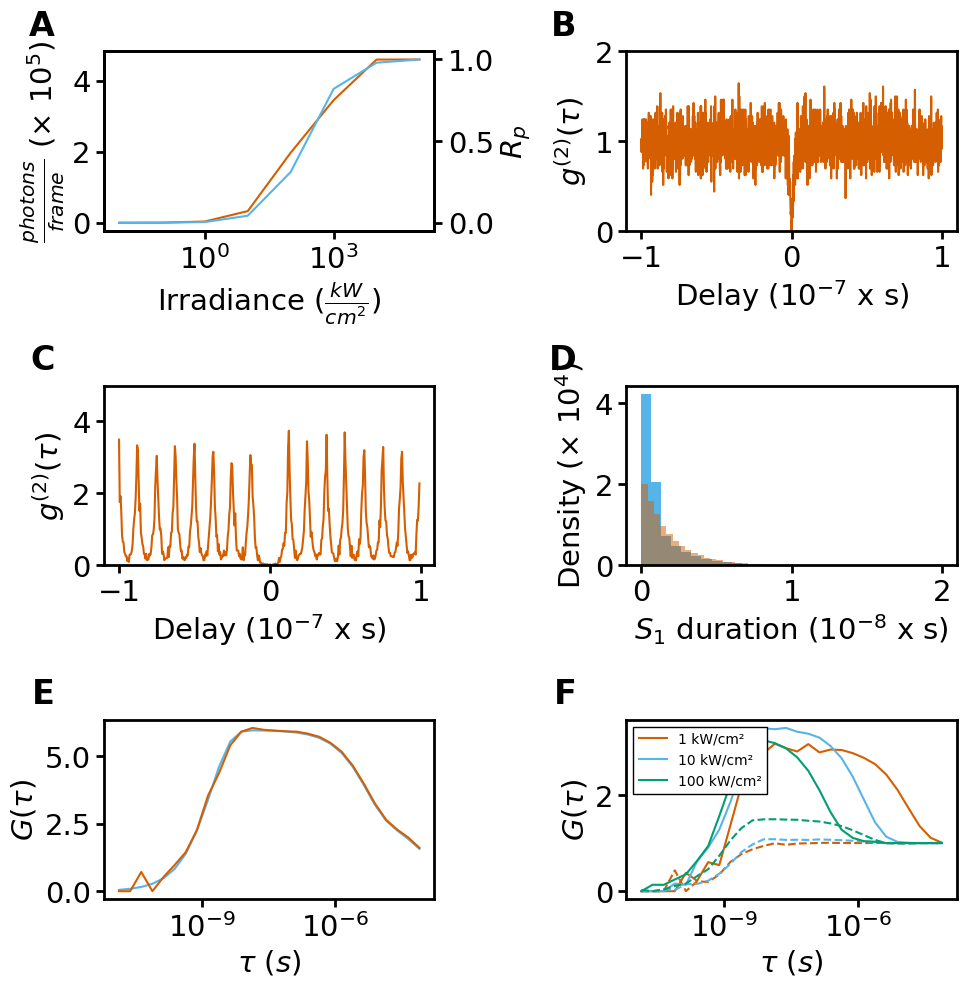

In [50]:
red = "#D55E00"
sky_blue = "#56B4E9"
green = "#009E73"
orange = "#E69F00"
colors = [red, sky_blue, green, orange]

rcParams["axes.linewidth"] = 2
gs = plt.GridSpec(3, 2)
fig = plt.figure(figsize=(10, 10))

ax1 = fig.add_subplot(gs[0, 0])
ax1_2 = ax1.twinx()
fi.universal_figure(
    axes=ax1,
    type_="line",
    data=[irradiances_saturation, photons_per_frame_collection_saturation],
    color=red,
    ylabel=r"$\frac{photons}{frame}$",
    xlabel=r"Irradiance ($\frac{kW}{cm^{2}}$)",
    tick_style_y="sci",
)
fi.universal_figure(
    axes=ax1_2,
    type_="line",
    data=[irradiances_saturation, relative_photon_rate_collection_saturation],
    color=sky_blue,
    xscale="log",
    yscale="linear",
    ylabel=r"$R_p$",
)
ax2 = fig.add_subplot(gs[0, 1])
fi.universal_figure(
    axes=ax2,
    type_="line",
    data=[bins_antibunch[:-2], hist_antibunch],
    ylim=[0, 2],
    ylabel=r"$g^{(2)}(\tau)$",
    xlabel="Delay (s)",
    color=red,
    tick_style_x="sci",
)
ax3 = fig.add_subplot(gs[1, 0])
fi.universal_figure(
    axes=ax3,
    type_="line",
    data=[bins_tcspc[:-2], hist_tcspc],
    ylim=[0, 5],
    ylabel=r"$g^{(2)}(\tau)$",
    xlabel="Delay (s)",
    color=red,
    tick_style_x="sci",
)
ax4 = fig.add_subplot(gs[1, 1])
fi.universal_figure(
    axes=ax4,
    type_="hist",
    data=lifetimes_alias_2,
    color=sky_blue,
    bins=30,
)
fi.universal_figure(
    axes=ax4,
    type_="hist",
    data=lifetimes_alias_1,
    color=red,
    bins=30,
    ylabel="Density",
    xlabel=r"$S_1$ duration (s)",
    alpha=0.5,
    tick_style_y="sci",
    tick_style_x="sci",
)
ax5 = fig.add_subplot(gs[2, 0])
fi.universal_figure(
    axes=ax5,
    type_="line",
    data=[fcs_to_fit.tau, fit_combined],
    label="fit",
    color=sky_blue,
)
fcs_to_fit.plot(axes=ax5, color=red, label="simulation", title=None)

ax6 = fig.add_subplot(gs[2, 1])
for i, (fcs, fcs2) in enumerate(zip(fcs_irradiance, fcs_irradiance_2)):
    fcs.plot(
        axes=ax6,
        color=colors[i],
        label=f"{irradiances_fcs[i]} kW/cm²",
        legend=True,
        title=None,
        legendargs=dict(
            framealpha=1,
            edgecolor="black",
            fancybox=False,
        ),
    )
    fcs2.plot(axes=ax6, color=colors[i], linestyle="--", title=None)

axes = fig.get_axes()
letters = ["A", "", "B", "C", "D", "E", "F"]
for i, axis in enumerate(axes):
    offset = -0.15
    axis.text(
        offset,
        1.05,
        letters[i],
        transform=axis.transAxes,
        fontsize=24,
        fontweight="bold",
        va="bottom",
        ha="right",
    )

fig.tight_layout()
fig.savefig(
    saving_at + r"\validations_1.png",
    dpi=300,
    bbox_inches="tight",
    pad_inches=0.1,
)

### <a id='toc1_7_2_'></a>[Figure 2](#toc0_)

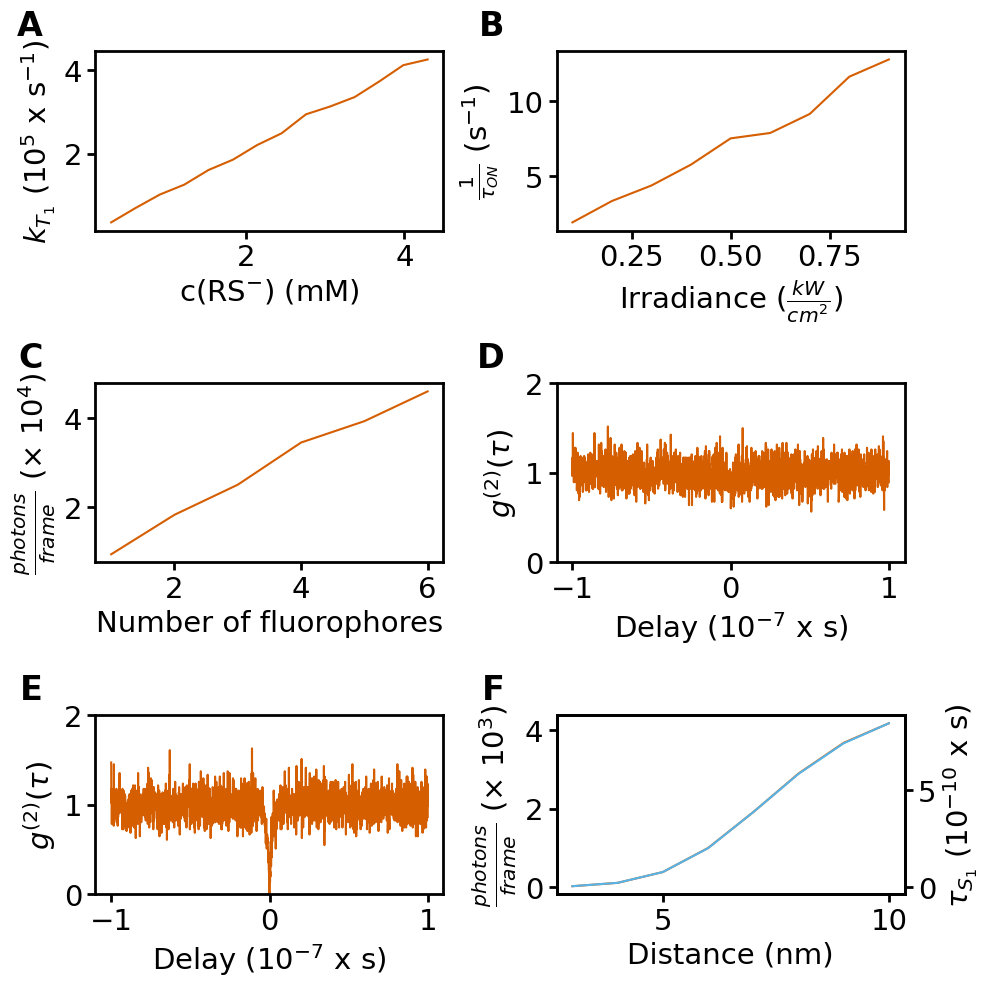

: 

In [ ]:
red = "#D55E00"
sky_blue = "#56B4E9"
green = "#009E73"
orange = "#E69F00"
colors = [red, sky_blue, green, orange]

rcParams["axes.linewidth"] = 2
gs = plt.GridSpec(3, 2)
fig = plt.figure(figsize=(10, 10))

ax1 = fig.add_subplot(gs[0, 0])
fi.universal_figure(
    axes=ax1,
    type_="line",
    data=[rs_concs, 1 / np.array(triplet_lifetimes)],
    color=red,
    ylabel=r"$k_{T_{1}}$ (s$^{-1}$)",
    xlabel=r"c(RS$^{-}$) (mM)",
    tick_style_y="sci",
)
ax2 = fig.add_subplot(gs[0, 1])
fi.universal_figure(
    axes=ax2,
    type_="line",
    data=[irradiances_on, 1 / np.array(on_times)],
    color=red,
    ylabel=r"$\frac{1}{\tau_{ON}}$ (s$^{-1}$)",
    xlabel=r"Irradiance ($\frac{kW}{cm^{2}}$)",
)
ax3 = fig.add_subplot(gs[1, 0])
fi.universal_figure(
    axes=ax3,
    type_="line",
    data=[num_fluorophores, photons_per_frame_collection_num_f],
    color=red,
    ylabel=r"$\frac{photons}{frame}$",
    xlabel="Number of fluorophores",
    tick_style_y="sci",
)
ax4 = fig.add_subplot(gs[1, 1])
fi.universal_figure(
    axes=ax4,
    type_="line",
    data=[bins_multi_f[:-2], hist_multi_f],
    ylim=[0, 2],
    ylabel=r"$g^{(2)}(\tau)$",
    xlabel="Delay (s)",
    color=red,
    tick_style_x="sci",
)
ax5 = fig.add_subplot(gs[2, 0])
fi.universal_figure(
    axes=ax5,
    type_="line",
    data=[bins_ssa[:-2], hist_ssa],
    ylim=[0, 2],
    ylabel=r"$g^{(2)}(\tau)$",
    xlabel="Delay (s)",
    color=red,
    tick_style_x="sci",
)
ax6 = fig.add_subplot(gs[2, 1])
ax6_2 = ax6.twinx()
fi.universal_figure(
    axes=ax6,
    type_="line",
    data=[distances, photons_per_frame_collection_distances],
    color=red,
    ylabel=r"$\frac{photons}{frame}$",
    xlabel="Distance (nm)",
    tick_style_y="sci",
)
fi.universal_figure(
    axes=ax6_2,
    type_="line",
    data=[distances, lifetime_collection],
    color=sky_blue,
    ylabel=r"$\tau_{S_{1}}$ (s)",
    xlabel="Distance (nm)",
    tick_style_y="sci",
)

axes = fig.get_axes()
letters = ["A", "B", "C", "D", "E", "F", ""]
for i, axis in enumerate(axes):
    offset = -0.15
    axis.text(
        offset,
        1.05,
        letters[i],
        transform=axis.transAxes,
        fontsize=24,
        fontweight="bold",
        va="bottom",
        ha="right",
    )

fig.tight_layout()
fig.savefig(
    saving_at + r"\validations_2.png",
    dpi=300,
    bbox_inches="tight",
    pad_inches=0.1,
)